In [1]:
import requests
import geopandas as gpd
import matplotlib.pyplot as plt

URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"

#211
#198
#124
#335

id = 198

scenario_response = requests.get(
    f"{URBAN_API}/scenarios/{id}"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_data = scenario_response.json()
project_id = scenario_data.get("project", {}).get("project_id")
if project_id is None:
    raise Exception("Project ID is missing in scenario data.")

territory_response = requests.get(
    f"{URBAN_API}/projects/{project_id}/territory"
        )

if territory_response.status_code != 200:
            raise Exception("Ошибка при получении геометрии территории")
        
territory_data = territory_response.json()
territory_geometry = territory_data["geometry"]
territory_feature = {
    'type': 'Feature',
    'geometry': territory_geometry,
    'properties': {}
}
polygon_gdf = gpd.GeoDataFrame.from_features([territory_feature], crs=4326)
polygon_gdf = polygon_gdf.to_crs(32636)


scenario_indicators_response = requests.get(
    f"{URBAN_API}/scenarios/{id}/indicators_values"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_indicators = scenario_indicators_response.json()

indicator_attributes = {
    indicator['indicator']['name_full']: indicator['value']
    for indicator in scenario_indicators
}

# Добавляем эти значения как колонки в polygon_gdf
for name, value in indicator_attributes.items():
    polygon_gdf[name] = value
    
polygon_gdf



,geometry,Численность населения,Население,Транспортное обеспечение,Экологическая ситуация,Обеспечение инженерной инфраструктурой,Социальное обеспечение,Средняя этажность,Коэффициент застройки,Коэффициент плотности застройки,...,Потенциал развития застройки общественно-деловой зоны,Потенциал развития среднеэтажной жилой застройки,Потенциал развития многоэтажной жилой застройки,Потенциал развития застройки рекреационной зоны,Потенциал развития застройки сельскохозяйственной зоны,Потенциал развития застройки зоны специального назначения,Потенциал развития застройки промышленной зоны,Потенциал развития застройки транспортной зоны,Срок рекультивации территории,Стоимость рекультивации территории
0,"POLYGON ((387861.999 6644712.938, 388202.551 6...",0.0,2.0,5.0,-2.66,5.0,4.0,2.0,0.2,0.05,...,2.0,3.0,1.0,4.0,3.0,3.0,4.0,4.0,6324.0,2.284321e+09


/home/mvin/Urbanomy/urbanomy/methods/investment_potential/land_use_score.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


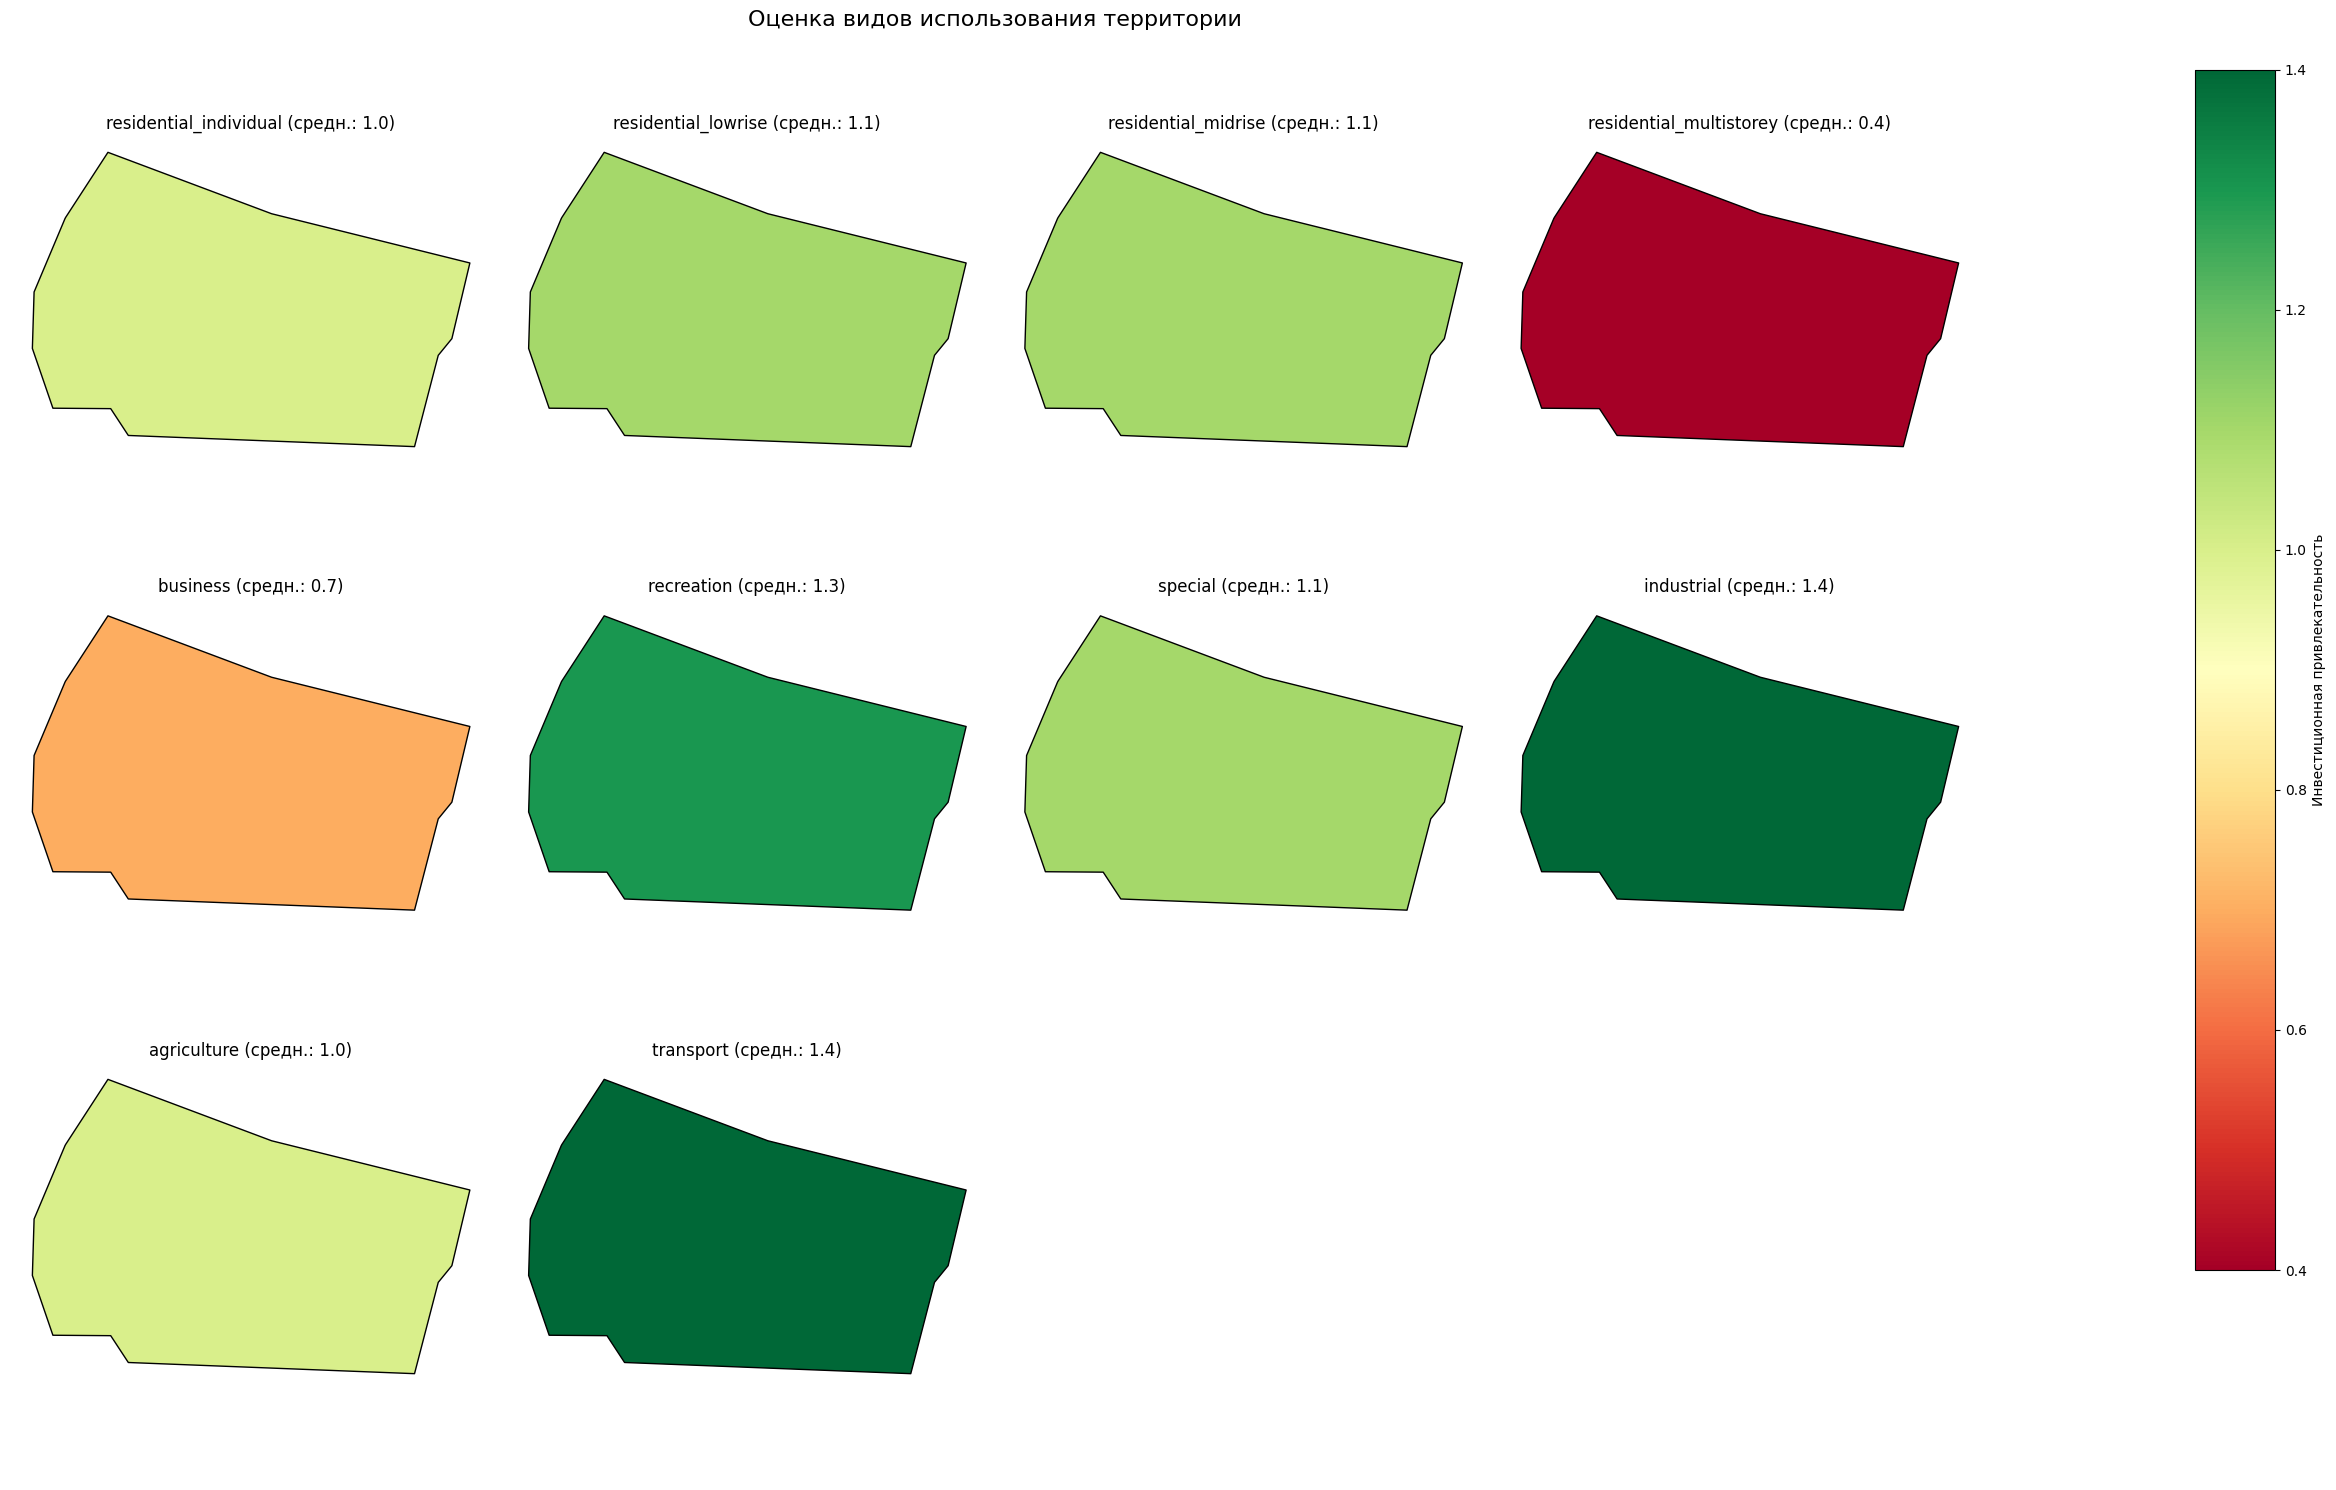

In [2]:
from urbanomy.methods.investment_potential import LandUseScoreAnalyzer

analyzer = LandUseScoreAnalyzer(weights=None)
spatial_gdf = analyzer.compute_scores(polygon_gdf)
fig = analyzer.visualize_investment_maps(spatial_gdf)
plt.show()

In [3]:
import geopandas as gpd
import random
from shapely.geometry import Point
from shapely.ops import voronoi_diagram



# 2. Объединяем все геометрии (если их несколько) в одну
base_poly = spatial_gdf.geometry.unary_union

# 3. Список колонок ИП
ip_cols = [col for col in spatial_gdf.columns if col.startswith("ИП_")]

# 4. Генерируем точки-«семена» внутри base_poly
minx, miny, maxx, maxy = base_poly.bounds
random.seed(42)
seed_points = []
for ip in ip_cols:
    while True:
        x = random.uniform(minx, maxx)
        y = random.uniform(miny, maxy)
        p = Point(x, y)
        if p.within(base_poly):
            seed_points.append(p)
            break

points_gdf = gpd.GeoDataFrame(
    {"ip_type": ip_cols},
    geometry=seed_points,
    crs=spatial_gdf.crs
)

# 5. Строим Вороного
vor = voronoi_diagram(points_gdf.unary_union, envelope=base_poly)
vor_polys = list(vor.geoms) if hasattr(vor, "geoms") else list(vor)

# 6. Собираем зоны в GeoDataFrame
zones = []
for cell in vor_polys:
    for idx, row in points_gdf.iterrows():
        if row.geometry.within(cell):
            zones.append({
                "ip_type":  row["ip_type"],
                "ip_value": spatial_gdf.iloc[0][row["ip_type"]],
                "geometry": cell
            })
            break

zones_gdf = gpd.GeoDataFrame(zones, crs=spatial_gdf.crs)

# === НОВЫЙ ШАГ: обрезаем зоны по исходному полигонам spatial_gdf ===
zones_gdf = gpd.clip(zones_gdf, spatial_gdf)


# 8. Сохраняем результат
zones_gdf


/tmp/ipykernel_140711/3707091699.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  base_poly = spatial_gdf.geometry.unary_union
/tmp/ipykernel_140711/3707091699.py:34: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  vor = voronoi_diagram(points_gdf.unary_union, envelope=base_poly)


,ip_type,ip_value,geometry
7,ИП_residential_individual,1.0,"POLYGON ((389460.139 6643570.686, 390172.418 6..."
3,ИП_residential_multistorey,0.4,"POLYGON ((389429.389 6643590.914, 389460.139 6..."
6,ИП_industrial,1.4,"POLYGON ((390172.418 6643549.388, 390334.954 6..."
5,ИП_residential_lowrise,1.1,"POLYGON ((389090.462 6643932.194, 388423.317 6..."
2,ИП_agriculture,1.0,"POLYGON ((389125.366 6643950.229, 389429.389 6..."
1,ИП_business,0.7,"POLYGON ((389112.984 6644150.75, 389125.366 66..."
4,ИП_recreation,1.3,"POLYGON ((389429.389 6643590.914, 389125.366 6..."
9,ИП_transport,1.4,"POLYGON ((390334.954 6643620.983, 390237.235 6..."
8,ИП_residential_midrise,1.1,"POLYGON ((390237.235 6644109.31, 389610.404 66..."
0,ИП_special,1.1,"POLYGON ((389112.984 6644150.75, 387644.932 66..."


In [4]:
# import matplotlib.pyplot as plt

# # Создаём фигуру побольше
# fig, ax = plt.subplots(figsize=(15, 15))

# # Рисуем на нашей оси
# zones_gdf.plot(
#     column="ip_type",
#     cmap="viridis",
#     legend=True,
#     ax=ax
# )

# # Убираем оси
# ax.set_axis_off()

# # Увеличиваем шрифт заголовка, если нужно
# plt.title("Зоны инвестиционного потенциала", fontsize=16)

# plt.show()


In [5]:
benchmarks_demo = {
    "residential_individual": {
        "density": 0.25,
        "land_cost": 1500,
        "cost_build": 48_000,
        "price_sale": 92_000,
        "construction_years": 2,
        "sale_years": 3,
        "opex_rate": 800,

    },
    "residential_lowrise": {
        "density": 0.5,
        "land_cost": 1800,
        "cost_build": 50_000,
        "price_sale": 95_000,
        "construction_years": 2,
        "sale_years": 3,
        "opex_rate": 900
    },
    "residential_midrise": {
        "density": 1.5,
        "land_cost": 2500,
        "cost_build": 55_000,
        "price_sale": 105_000,
        "construction_years": 3,
        "sale_years": 4,
        "opex_rate": 1_200
    },
    "residential_multistorey": {
        "density": 3.0,
        "land_cost": 3000,
        "cost_build": 62_000,
        "price_sale": 120_000,
        "construction_years": 4,
        "sale_years": 5,
        "opex_rate": 1_500
    },
    "business": {
        "density": 2.0,
        "land_cost": 2800,
        "cost_build": 55_000,
        "rent_annual": 14_000,
        "rent_years": 12,
        "occupancy": 0.85,
        "construction_years": 3,
        "opex_rate": 1_300
    },
    "recreation": {
        "density": 0.2,
        "land_cost": 1000,
        "cost_build": 40_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "occupancy": 0.7,
        "construction_years": 2,
        "opex_rate": 1_000
    },
    "special": {
        "density": 1.0,
        "land_cost": 1200,
        "cost_build": 45_000,
        "rent_annual": 8_000,
        "rent_years": 15,
        "occupancy": 0.8,
        "construction_years": 3,
        "opex_rate": 1_500
    },
    "industrial": {
        "density": 1.0,
        "land_cost": 900,
        "cost_build": 38_000,
        "rent_annual": 5_800,
        "rent_years": 12,
        "occupancy": 0.9,
        "construction_years": 2,
        "opex_rate": 700
    },
    "agriculture": {
        "density": 0.1,
        "land_cost": 300,
        "cost_build": 25_000,
        "rent_annual": 2_500,
        "rent_years": 15,
        "occupancy": 0.95,
        "construction_years": 1,
        "opex_rate": 300
    },
    "transport": {
        "density": 1.2,
        "land_cost": 1_100,
        "cost_build": 32_000,
        "rent_annual": 4_200,
        "rent_years": 15,
        "occupancy": 0.88,
        "construction_years": 3,
        "opex_rate": 600
    }
}

In [6]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
gdf_out, summary = an.calculate_investment_metrics(zones_gdf)
summary

/home/mvin/Urbanomy/urbanomy/methods/investment_potential/investment_metrics.py:148: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary.loc["project"] = {


,NPV,IRR,ROI,PP_years,EI,investment_attractiveness,INV
profile,,,,,,,
residential_individual,1394131023.18,0.22,2.19,4.34,78.67,1.00,79.87
residential_lowrise,4437204500.27,0.24,2.35,4.23,84.48,1.10,88.00
residential_midrise,2678973065.04,0.18,3.18,6.24,66.06,1.10,74.10
residential_multistorey,2748942668.07,0.14,4.00,8.56,55.08,0.40,32.60
business,2237508700.13,0.13,4.59,14.25,51.57,0.70,51.73
recreation,-4640501513.22,0.02,1.33,NaN,0.00,1.30,54.00
special,-17402909540.60,0.06,2.69,NaN,0.00,1.10,21.00
industrial,-4853344624.66,0.05,1.77,NaN,0.00,1.40,35.00
agriculture,-556140242.00,0.01,1.11,NaN,0.19,1.00,36.09
